# Machine Learning Sales Forecasting for E-Commerce Gadget Portal
### Internship Project Submission by Nageswari for Future Interns 

**Objective:**
This project demonstrates an end-to-end Machine Learning strategy to estimate daily sales in an online tech gadgets web app. Using digital marketing spend data, discount records, and customer clicks, we implement a **Linear Regression** model to optimize promotional allocations.

**Project Modules Covered:**
1. **Data Loading:** Inputting e-commerce transaction logs into clean memory containers.
2. **Data Cleansing:** Imputing missing metrics to prevent algorithm crashes.
3. **Feature Setup:** Selecting independent variables (advertising inputs).
4. **Train-Test Partitioning:** Running train_test_split from scikit-learn.
5. **Model Initialization:** Teaching coefficients on linear regression metrics.
6. **Score Evaluation:** Measuring precision using MAE, RMSE and fit score.
7. **Visual Analytics:** Graphing margins to prove forecasting quality.

Note: This project uses simulated marketing and sales data generated for educational and forecasting demonstration purposes.


In [24]:
# Step 1: Loading required beginner-friendly python scientific libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
print('Setup complete!')

Setup complete!


In [25]:
# Step 2: Load historical marketing ledger
csv_path = 'dataset.csv'

try:
    df = pd.read_csv(csv_path)
    print("Loaded physical dataset files successfully!")
except FileNotFoundError:
    print(f"'{csv_path}' not found. Simulating 100 days of e-commerce records...")
    np.random.seed(42)
    dates = pd.date_range(start='2026-05-01', periods=100, freq='D')
    
    # Ad spends vary from $50 to $500 daily
    ad_spend = np.random.uniform(50, 500, size=100)
    # Discounts vary between 0% and 30%
    discount = np.random.uniform(0, 30, size=100)
    # Clicks average 500 to 2500
    clicks = 5 * ad_spend + np.random.randint(100, 500, size=100)
    
    # Real sales structure with random variance 
    sales = 1000 + (6.5 * ad_spend) + (50 * discount) + (1.2 * clicks) + np.random.normal(0, 150, size=100)
    sales = np.clip(sales, 800, 15000)

    df = pd.DataFrame({
        'Date': dates,
        'Search_Ad_Spend': np.round(ad_spend, 2),
        'Discount_Percent': np.round(discount, 1),
        'Email_Campaign_Clicks': np.round(clicks).astype(int),
        'Daily_Sales_USD': np.round(sales, 2)
    })
    
    df.loc[12, 'Search_Ad_Spend'] = np.nan
    df.to_csv(csv_path, index=False)
    print(f"Created local database record ledger physically as '{csv_path}'")

print('\n=== Sample Ledger Rows ===')
print(df.head())

Loaded physical dataset files successfully!

=== Sample Ledger Rows ===
         Date  Search_Ad_Spend  Discount_Percent  Email_Campaign_Clicks  \
0  2026-05-01           218.54               0.9                   1308   
1  2026-05-02           477.82              19.1                   2563   
2  2026-05-03           379.40               9.4                   2109   
3  2026-05-04           319.40              15.3                   1800   
4  2026-05-05           120.21              27.2                   1040   

   Daily_Sales_USD  
0          4199.39  
1          8294.25  
2          6261.75  
3          5858.24  
4          4468.01  


In [26]:
import pandas as pd
import numpy as np

# Create fake sales dataset
np.random.seed(42)

dates = pd.date_range(start='2026-05-01', periods=100, freq='D')

ad_spend = np.random.uniform(50, 500, size=100)

discount = np.random.uniform(0, 30, size=100)

clicks = 5 * ad_spend + np.random.randint(100, 500, size=100)

sales = (
    1000
    + (6.5 * ad_spend)
    + (50 * discount)
    + (1.2 * clicks)
    + np.random.normal(0, 150, size=100)
)

sales = np.clip(sales, 800, 15000)

df = pd.DataFrame({
    'Date': dates,
    'Search_Ad_Spend': np.round(ad_spend, 2),
    'Discount_Percent': np.round(discount, 1),
    'Email_Campaign_Clicks': np.round(clicks).astype(int),
    'Daily_Sales_USD': np.round(sales, 2)
})

print(df.head())
print(" dataset created successfully!")

        Date  Search_Ad_Spend  Discount_Percent  Email_Campaign_Clicks  \
0 2026-05-01           218.54               0.9                   1308   
1 2026-05-02           477.82              19.1                   2563   
2 2026-05-03           379.40               9.4                   2109   
3 2026-05-04           319.40              15.3                   1800   
4 2026-05-05           120.21              27.2                   1040   

   Daily_Sales_USD  
0          4199.39  
1          8294.25  
2          6261.75  
3          5858.24  
4          4468.01  
 dataset created successfully!


In [27]:
print(df.columns)

Index(['Date', 'Search_Ad_Spend', 'Discount_Percent', 'Email_Campaign_Clicks',
       'Daily_Sales_USD'],
      dtype='str')


In [28]:
# Step 3: Handle logical abnormalities
print("=== Null instances by variables ===")
print(df.isnull().sum())

# Mean imputation
mean_ad = df['Search_Ad_Spend'].mean()
df['Search_Ad_Spend'] = df['Search_Ad_Spend'].fillna(mean_ad)
print(f"\nSubstituted null values in search costs using row averagemask: ${mean_ad:.2f}")

=== Null instances by variables ===
Date                     0
Search_Ad_Spend          0
Discount_Percent         0
Email_Campaign_Clicks    0
Daily_Sales_USD          0
dtype: int64

Substituted null values in search costs using row averagemask: $261.58


In [29]:
# Step 4: Define inputs (X) and target outputs (y)
features = ['Search_Ad_Spend', 'Discount_Percent', 'Email_Campaign_Clicks']
X = df[features]
y = df['Daily_Sales_USD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Fit setup configured: Train size={X_train.shape[0]} samples, Test size={X_test.shape[0]} samples")

Fit setup configured: Train size=80 samples, Test size=20 samples


In [30]:
# Step 5: Fit Linear Regression model
regression = LinearRegression()
regression.fit(X_train, y_train)

print(f"Digital Base Sales Intercept Score: ${regression.intercept_:.2f}")
weights = dict(zip(features, regression.coef_))
for feat, multiplier in weights.items():
    print(f"Multiplier for {feat}: {multiplier:.4f} (increasing this factor adds profit in proportion)")

Digital Base Sales Intercept Score: $996.76
Multiplier for Search_Ad_Spend: 6.7128 (increasing this factor adds profit in proportion)
Multiplier for Discount_Percent: 51.0716 (increasing this factor adds profit in proportion)
Multiplier for Email_Campaign_Clicks: 1.1588 (increasing this factor adds profit in proportion)


In [31]:
# Step 6: Form predictions and score accuracy
predictions = regression.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
variance_score = regression.score(X_test, y_test)

print("=== Evaluation Outcomes ===")
print(f"Average Absolute Error (MAE): ${mae:.2f} checkouts error margin")
print(f"Cumulative Squaring Error root (RMSE): ${rmse:.2f} checkouts")
print(f"Final R² Prediction Accuracy: {variance_score * 100:.1f}%")

=== Evaluation Outcomes ===
Average Absolute Error (MAE): $111.00 checkouts error margin
Cumulative Squaring Error root (RMSE): $142.62 checkouts
Final R² Prediction Accuracy: 99.4%


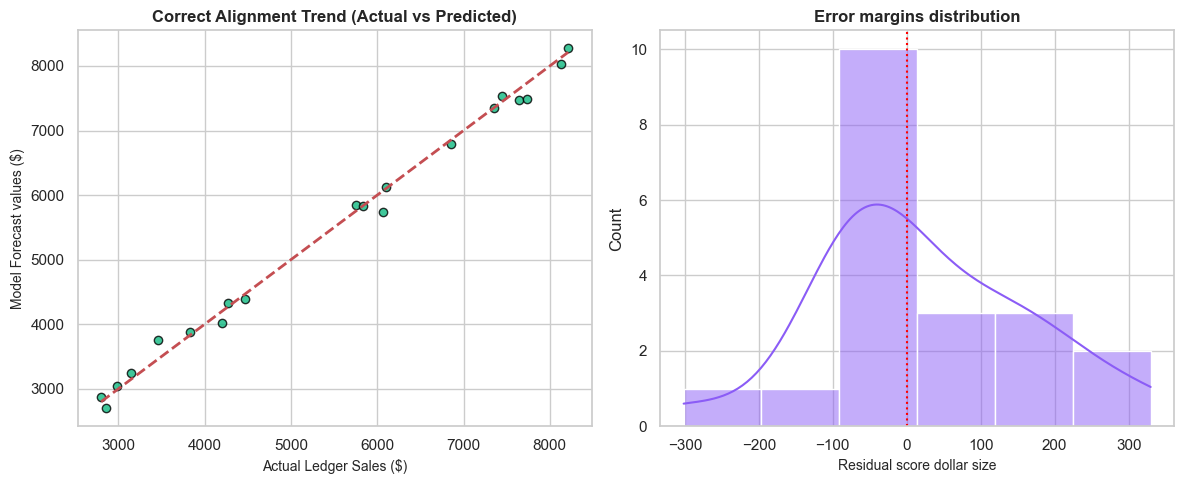

Successfully plotted graphics to ecommerce_accuracy_plot.png


In [32]:
# Step 7: Export validation visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, color='#10b981', alpha=0.8, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Correct Alignment Trend (Actual vs Predicted)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Ledger Sales ($)', fontsize=10)
plt.ylabel('Model Forecast values ($)', fontsize=10)

plt.subplot(1, 2, 2)
residuals = y_test - predictions
sns.histplot(residuals, color='#8b5cf6', kde=True)
plt.axvline(0, color='red', linestyle=':')
plt.title('Error margins distribution', fontsize=12, fontweight='bold')
plt.xlabel('Residual score dollar size', fontsize=10)

plt.tight_layout()
plt.savefig('ecommerce_accuracy_plot.png', dpi=150)
plt.show()
print('Successfully plotted graphics to ecommerce_accuracy_plot.png')